## Introduction to Neural Networks

Neural networks are a type of machine learning model inspired by the human brain.  
They can model complex relationships between inputs and outputs, and are foundational to deep learning.

In this notebook we will cover:

1. Perceptron: Basic building block
2. Feedforward Neural Networks: Layers and activation functions
3. Gradient Descent and Backpropagation: How neural networks learn
4. Overfitting and Underfitting: Concepts and mitigation techniques
5. Hands-on Exercise: Train a small neural network


## 1. Perceptron: Basic Building Block

A **perceptron** is a single neuron that computes a weighted sum of inputs, adds a bias, and passes it through an activation function:

<img src="https://ars.els-cdn.com/content/image/3-s2.0-B9780128233375000020-f02-01-9780128233375.jpg" width="800">



Mathematical formula:

$$
y = f\left(\sum_{i=1}^{n} w_i x_i + b\right)
$$

Where:
- $x_i$ = input features
- $w_i$ = weights
- $b$ = bias
- $f$ = activation function (step, sigmoid, etc.)



In [ ]:
# Perceptron AND gate animation
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# AND gate dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,0,0,1])

# Initialize weights and bias
np.random.seed(0)
w = np.random.rand(2)
b = np.random.rand()
lr = 0.1

# Step function
def step(x):
    return 1 if x >= 0 else 0

# Create plot
fig, ax = plt.subplots(figsize=(5,5))
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Perceptron Learning - AND Gate")

# Scatter plot (blue=0, red=1)
colors = ['blue' if label == 0 else 'red' for label in y]
ax.scatter(X[:,0], X[:,1], c=colors, s=100, edgecolors='k')

# Decision boundary line
line, = ax.plot([], [], 'k--', linewidth=2)

# Function to update decision boundary
def update_boundary(w, b):
    x_vals = np.array(ax.get_xlim())
    if w[1] != 0:
        y_vals = -(w[0]*x_vals + b) / w[1]
        line.set_data(x_vals, y_vals)
    else:
        line.set_data([], [])

# Animation function
def animate(epoch):
    global w, b
    # Train for one epoch
    for i in range(len(X)):
        linear_output = np.dot(w, X[i]) + b
        y_pred = step(linear_output)
        error = y[i] - y_pred
        w += lr * error * X[i]
        b += lr * error

    update_boundary(w, b)
    ax.set_title(f"Epoch {epoch+1} | w={w.round(2)}, b={b:.2f}")
    return line,

# Create animation
anim = FuncAnimation(fig, animate, frames=20, interval=500, repeat=False)

# Prevent duplicate static plot
plt.close(fig)

# Display only the animation
HTML(anim.to_html5_video())


## 2. Feedforward Neural Networks

A **feedforward neural network** or multi layer perceptron (MLP) consists of multiple layers:

- **Input layer**: receives features
- **Hidden layers**: process information
- **Output layer**: produces predictions

<img src="https://ars.els-cdn.com/content/image/1-s2.0-S0925231223004502-gr1.jpg" width="700">

### Forward Pass Equation

For a network with one hidden layer:

$$
\begin{align}
\mathbf{z}^{(1)} &= \mathbf{W}^{(1)} \mathbf{x} + \mathbf{b}^{(1)} \\
\mathbf{a}^{(1)} &= f(\mathbf{z}^{(1)}) \\
\mathbf{z}^{(2)} &= \mathbf{W}^{(2)} \mathbf{a}^{(1)} + \mathbf{b}^{(2)} \\
\mathbf{y}_{pred} &= f_{out}(\mathbf{z}^{(2)})
\end{align}
$$

Where:
- $ \mathbf{x} $ = input vector  
- $ \mathbf{W}^{(l)}, \mathbf{b}^{(l)} $ = weights and biases of layer \(l\)  
- $ f $ = activation function for hidden layers  
- $ f_{out} $ = activation function for output (e.g., identity for regression, sigmoid for binary classification)


### **Activation Functions**

Common Activation Functions

1. Sigmoid
$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$
- Range: (0, 1)  
- Pros: Smooth, outputs interpretable as probabilities  
- Use case: Binary classification output
- Cons: Vanishing gradient

2. Tanh
$$
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
$$  
- Range: (-1, 1)  
- Pros: Zero-centered, smoother gradients than sigmoid  
- Use case: Hidden layers in some networks

3. ReLU
$$
\text{ReLU}(x) = \max(0, x)
$$  
- Range: [0, ∞)  
- Pros: Simple, efficient, avoids vanishing gradient  
- Use case: Hidden layers (most common in modern networks)
- Cons: Dying ReLU

4. Leaky ReLU
$$
\text{LeakyReLU}(x) =
\begin{cases}
x & x \ge 0 \\
\alpha x & x < 0
\end{cases}
$$  
- Pros: Fixes dying ReLU problem  
- Use case: Hidden layers

5. Softmax
$$
\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}
$$  
- Range: (0,1), sums to 1 across vector  
- Pros: Converts logits to probabilities  
- Use case: Multi-class classification output

6. Linear / Identity
$$
f(x) = x
$$  
- Range: (-∞, ∞)  
- Pros: Simple, used for continuous output  
- Use case: Regression output layer


Activation Functions Visualization:

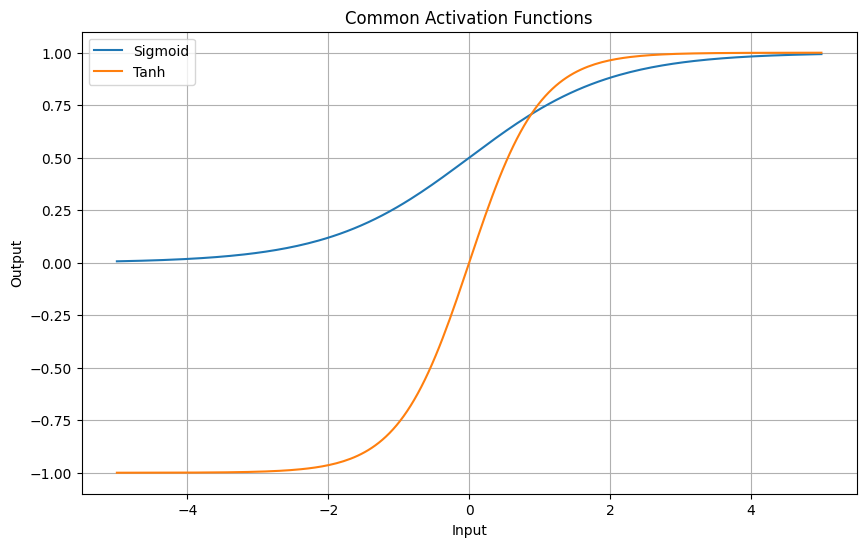

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Define activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.1):
    return np.where(x >= 0, x, alpha * x)

def tanh(x):
    return np.tanh(x)

def linear(x):
    return x

def softmax(x):
    e_x = np.exp(x - np.max(x))  # for numerical stability
    return e_x / e_x.sum()

# Input values
x_vals = np.linspace(-5, 5, 200)

# For softmax, create a 2D example for visualization
softmax_vals = np.array([softmax(np.array([i, 0, -i]))[0] for i in x_vals])

# Plot all functions
plt.figure(figsize=(10,6))
plt.plot(x_vals, sigmoid(x_vals), label='Sigmoid')
#plt.plot(x_vals, relu(x_vals), label='ReLU')
#plt.plot(x_vals, leaky_relu(x_vals), label='Leaky ReLU')
plt.plot(x_vals, tanh(x_vals), label='Tanh')
#plt.plot(x_vals, linear(x_vals), label='Linear')
#plt.plot(x_vals, softmax_vals, label='Softmax (first component)')

plt.title("Common Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.grid(True)
plt.show()


**Why are activation functions important?:**
These functions introduce **non-linearity**, allowing the network to model complex relationships between inputs and outputs.


## 3. Gradient Descent and Backpropagation

### **Training Neural Networks: Loss, Gradient Descent, and Backpropagation**  

Neural networks are trained by **minimizing a loss function** that measures the difference between the predicted output and the true label.  

A common choice for regression is the **Mean Squared Error (MSE)**:

$$
L = \frac{1}{2} \sum (y_{true} - y_{pred})^2
$$

For classification tasks, one might instead use **Cross-Entropy Loss**:

$$
L = -\sum y_{true} \log(y_{pred})
$$

#### **Gradient Descent**  

Training proceeds by updating the model parameters (weights, biases) in the direction that reduces the loss.  

A simple **gradient descent** update is:

$$
w := w - \alpha \frac{\partial L}{\partial w}
$$

where:  
- $ w $ = weight parameter  
- $ \alpha $ = learning rate  
- $ \frac{\partial L}{\partial w} $ = gradient of the loss w.r.t. $w$   


Variants of gradient descent include:  
- **Batch Gradient Descent** – uses the entire dataset each update (accurate but slow).  
- **Stochastic Gradient Descent (SGD)** – updates using a single random sample (faster, noisier).  
- **Mini-Batch Gradient Descent** – compromise, using small random subsets.  

Other advanced optimizers (like **Momentum, RMSProp, Adam**) adjust learning rates dynamically or use past gradient information for faster convergence.


<img src="https://miro.medium.com/v2/resize:fit:640/format:webp/1*hUd744hDEEGx0-ypWGhrkw.gif" width="500">



In [ ]:
# Gradient example for a single weight
y_true = 0.7
y_pred = 0.5
error = y_pred - y_true

grad = error  # gradient of MSE w.r.t output
learning_rate = 0.1
w = 0.8
w_new = w - learning_rate * grad
print(f"Old weight: {w}, New weight: {w_new:.4f}")

Old weight: 0.8, New weight: 0.8200


#### **Backpropagation**

Backpropagation is the **algorithm that efficiently computes gradients** for all network parameters using the **chain rule** of calculus.  

Consider a neural network as a composition of functions:

$$
y = f(x; w) = f^{(L)}(f^{(L-1)}(\dots f^{(1)}(x; w^{(1)}) \dots ))
$$

To update weights in layer \(l\), we need:

$$
\frac{\partial L}{\partial w^{(l)}}
$$



Backpropagation works in two main steps:  

1. **Forward Pass** – compute predictions layer by layer and evaluate the loss.  
2. **Backward Pass** – propagate gradients backwards:  

   $$
   \frac{\partial L}{\partial w^{(l)}} = \frac{\partial L}{\partial a^{(l)}} \cdot \frac{\partial a^{(l)}}{\partial z^{(l)}} \cdot \frac{\partial z^{(l)}}{\partial w^{(l)}}
   $$  

   where $a^{(l)}$ is the activation and $z^{(l)}$ is the pre-activation (linear combination of inputs and weights).  

By applying the chain rule layer by layer, backpropagation allows **all parameters to be updated efficiently**, even in deep networks.


## 4. Overfitting and Underfitting

### Underfitting vs. Overfitting  

- **Underfitting:**  
  - Occurs when the model is too simple to capture the underlying patterns in the data.  
  - Results in poor performance on both the **training set** and the **test set**.  

- **Overfitting:**  
  - Occurs when the model is too complex and learns not only the true patterns but also the noise in the training data.  
  - Results in very good performance on the **training set** but poor performance on the **test set** (poor generalization).  



<img src="https://www.mathworks.com/discovery/overfitting/_jcr_content/mainParsys/image.adapt.full.medium.svg/1746469504474.svg" width="800">

#### Bias-Variance Tradeoff and Its Relation to Overfitting and Underfitting

The **bias-variance tradeoff** is a fundamental concept in machine learning that explains the source of errors in predictive models.


#### **1. Bias**

- Bias measures the **error due to overly simplistic assumptions** in the model.  
- High bias → model is too simple → **underfitting**.  
- The model cannot capture the underlying patterns of the data.  

**Example:** A linear model trying to fit a highly nonlinear dataset.


#### **2. Variance**

- Variance measures the **error due to sensitivity to training data fluctuations**.  
- High variance → model is too complex → **overfitting**.  
- The model captures noise along with the signal and fails to generalize.  

**Example:** A very deep neural network memorizing the training data.


#### **3. Total Error**

The total expected error of a model can be decomposed as:

$$
\text{Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise}
$$

- **Bias²:** Error from wrong assumptions (underfitting).  
- **Variance:** Error from sensitivity to training data (overfitting).  
- **Irreducible Noise:** Randomness in the data.


#### **4. Relation to Training/Validation Curves**

- **Underfitting (High Bias, Low Variance):**  

- **Overfitting (Low Bias, High Variance):**  

The goal is to **balance bias and variance** to achieve the lowest validation error — this is the sweet spot of the bias-variance tradeoff.


<img src="https://media.geeksforgeeks.org/wp-content/uploads/20200107023418/1_oO0KYF7Z84nePqfsJ9E0WQ.png" width="700">



### Techniques to Mitigate Overfitting  

#### 1. Regularization  
Regularization adds a **penalty term** to the loss function that discourages overly large weights. This prevents the model from becoming too sensitive to small fluctuations in the data.  

- **L2 Regularization (Ridge):**  
  Adds a penalty proportional to the sum of squared weights:  

  $$
  L_{reg} = L + \lambda \sum w^2
  $$  

  Example: In linear regression, L2 regularization shrinks weights smoothly, spreading importance across features.  

- **L1 Regularization (Lasso):**  
  Adds a penalty proportional to the sum of absolute weights:  

  $$
  L_{reg} = L + \lambda \sum |w|
  $$  

  Example: In linear regression, L1 can drive some weights exactly to zero, effectively performing **feature selection**.  

---

🔑 **What is $\lambda$?**  
 $\lambda$ (the *regularization parameter*) controls the strength of the penalty:  
- If $\lambda = 0$, there is **no regularization** (the model may overfit).  
- If $\lambda$ is too large, the weights are heavily penalized, which may cause **underfitting**.  
- Choosing $\lambda$ properly (often via cross-validation) balances **fit vs. generalization**.  


#### 2. Dropout  
Dropout is a technique specific to neural networks. During training, a random subset of neurons is "dropped" (set to zero) in each forward pass.  

- This prevents the network from **relying too heavily on specific neurons**, encouraging more robust feature learning.  
- At test time, all neurons are used but their outputs are scaled to account for dropout during training.  

Example: With a dropout rate of 0.5, half of the neurons in a hidden layer are randomly turned off at each training step. This makes the model less likely to memorize the training set and more likely to generalize.  


<img src="https://towardsdatascience.com/wp-content/uploads/2022/07/1wDGvx0z0-nEB8zQHykvwPw.png" width="700">


#### 3. Early Stopping  
Early stopping monitors the model’s performance on a **validation set** during training.  

- As training progresses, validation performance typically improves up to a point and then begins to worsen due to overfitting.  
- Early stopping halts training at the point of **best validation performance**, preventing the model from overfitting further.  

Example: If after 50 epochs the validation loss stops decreasing but the training loss continues to decrease, we stop training at epoch 50.  


## 5. Example



In this example, we will use a **feedforward neural network** to classify iris flowers into three species:

1. Setosa
2. Versicolor
3. Virginica

We will go through all steps clearly:  
- Data loading and exploration  
- Training the neural network  
- Evaluation  
- Visualizations

Step 1: Load and Explore the Data:

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd
import seaborn as sns

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Convert to DataFrame for easy exploration
df = pd.DataFrame(X, columns=feature_names)
df['species'] = pd.Categorical.from_codes(y, target_names)
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


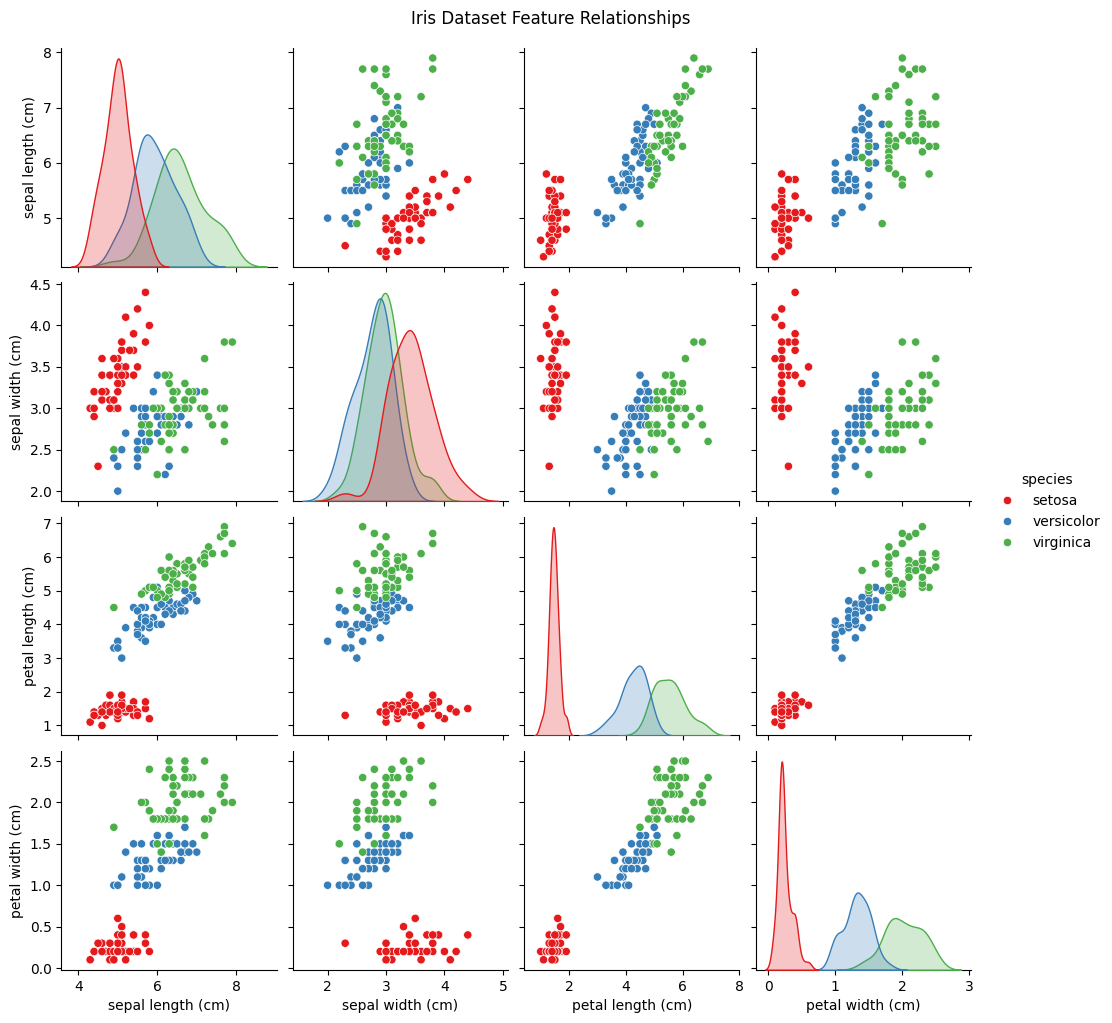

In [ ]:
# Pairplot to visualize feature relationships
sns.pairplot(df, hue='species', palette='Set1')
plt.suptitle("Iris Dataset Feature Relationships", y=1.02)
plt.show()


**Observation:**  
We can see that some species are linearly separable on certain features, while others overlap. This is ideal to see how a neural network handles classification.


Step 2: Prepare Data for Training:

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features for better training
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# One-hot encode labels
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)


Step 3: Build and Train the Neural Network:

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Define a simple feedforward network
model = Sequential([
    Dense(10, input_dim=4, activation='relu'),  # hidden layer
    Dense(3, activation='softmax')              # output layer for 3 classes
])

# Compile model
model.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train_cat, validation_data=(X_test, y_test_cat), epochs=100, verbose=0)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Step 4: Evaluate the Model:

In [ ]:
# Evaluate on test data
from sklearn.metrics import classification_report
import numpy as np

# 1. Get predicted probabilities
y_pred_prob = model.predict(X_test)

# 2. Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)  # predicted class indices
y_true = np.argmax(y_test_cat, axis=1)   # true class indices

# 3. Generate classification report
report = classification_report(y_true, y_pred)
print(report)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



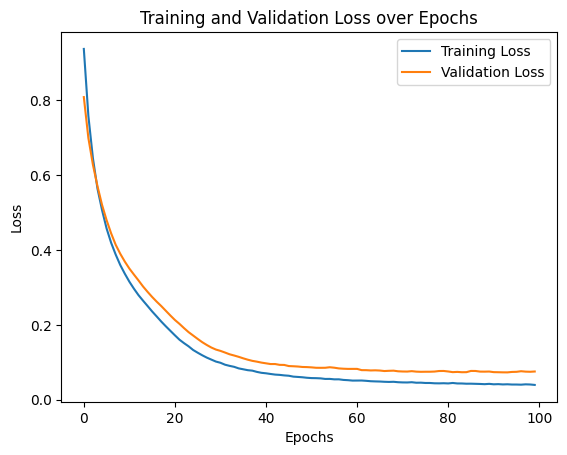

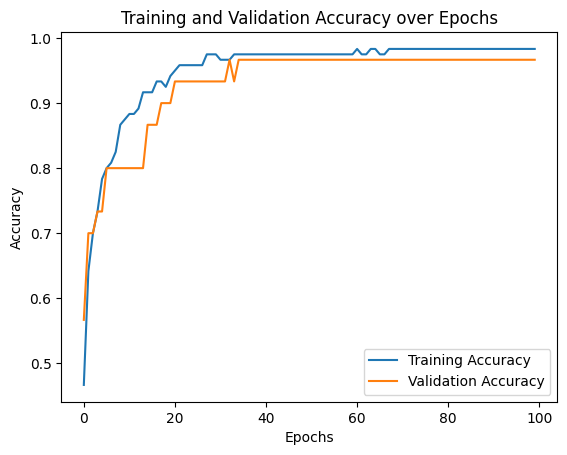

In [ ]:
# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.show()

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.legend()
plt.show()


Step 5: Visualize Predictions:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


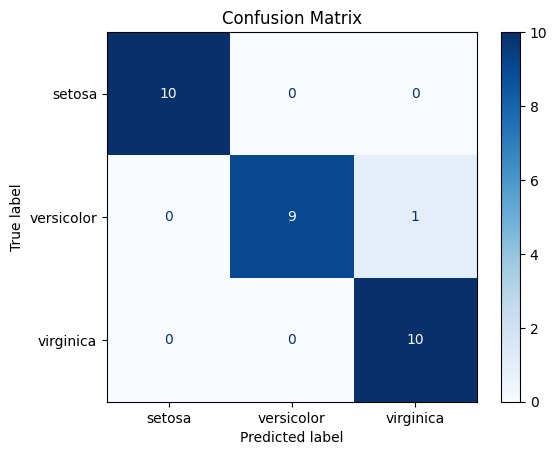

In [ ]:
import numpy as np

# Predict class probabilities
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


**Summary of the Classification Example:**

- We loaded the **Iris dataset** and visualized relationships between features.  
- Features were **scaled**, and labels were one-hot encoded for the network.  
- A small **feedforward neural network** was trained to classify species.  
- We monitored **training and validation loss/accuracy** to ensure proper learning.  
- The **confusion matrix** shows how well the network predicts each class.


## 6. Hyperparameter Tuning

After exploring the main components of neural networks, we can now step back and look at how **hyperparameter tuning** shapes model performance and generalization.

Hyperparameters are not learned by the network — they are the **choices we make before training** that control *how* the model learns.  
These include parameters like **learning rate**, **batch size**, **number of epochs**, **architecture depth**, **regularization strength**, and others.


### **1. Learning Rate (η)**

- **What it is:** Controls how much the model’s weights change in response to the gradient during training.  
- **Too small:** Learning is very slow and may get stuck in local minima.  
- **Too large:** Model overshoots the optimal weights and can diverge (loss jumps around or increases).  

**Tip:** Start with moderate values (e.g., `0.001–0.01` for Adam) and use learning rate schedules for stability.


### **2. Batch Size**

- **What it is:** Number of samples processed before the model updates its weights once.  
- **Small batch (e.g., 16–64):**
  - Noisier updates that may help generalization.
  - Slower training (more updates per epoch).  
- **Large batch (e.g., 256+):**
  - Faster on GPUs, smoother gradients.
  - Risk of overfitting, may generalize worse.

**Trade-off:** Smaller batches = better generalization; larger batches = faster convergence.


### **3. Number of Epochs**

- **What it is:** One epoch = one full pass over the training data.  
- **Too few:** Underfitting (model hasn’t learned enough).  
- **Too many:** Overfitting (model memorizes the data).  

**Tip:** Use **early stopping** to automatically stop training when validation loss stops improving.


### **4. Number of Layers / Neurons**

- **Deeper or wider networks** increase model capacity and allow learning more complex patterns.  
- **Too small:** Model underfits (too simple).  
- **Too large:** Model overfits, trains slower, and may require more data.  

**Rule of thumb:** Start simple — add layers or neurons only if validation accuracy plateaus.


### **5. Activation Functions**

- **Common choices:** `ReLU`, `tanh`, `sigmoid`.  

**Modern practice:** Use **ReLU** or its variants (`LeakyReLU`, `ELU`) for most hidden layers.


### **6. Optimizer**

- **Controls how weights are updated during training.**  
- **SGD:** Simple, can generalize well but slower.  
- **Adam:** Adaptive and fast, works well for most problems.  
- **RMSProp / Adagrad:** Handle non-stationary objectives well.  

**Tip:** Start with **Adam**; try **SGD with momentum** if overfitting occurs.


### **7. Regularization**

- **Purpose:** Prevent overfitting by penalizing overly complex models.  
- **Types:**
  - `L2` weight decay (smooths weights)
  - `Dropout` (randomly disables neurons)
  - `Early stopping` (stops training early)  

**Trade-off:** Too much regularization → underfitting; too little → overfitting.


### **8. Learning Rate Schedule**

- **Why:** Models often need a higher learning rate at the start and smaller later.  
- **Methods:**
  - Step decay
  - Exponential decay
  - Cosine annealing
  - Reduce on plateau  

**Tip:** Using a schedule usually improves convergence and reduces oscillations.


### **Summary Table**

| Hyperparameter | Low Value → | High Value → | Typical Range |
|----------------|-------------|--------------|----------------|
| Learning Rate | Slow / stuck | Unstable / diverging | 1e-4 – 1e-2 |
| Batch Size | Noisy / generalizes well | Smooth / may overfit | 16 – 256 |
| Epochs | Underfitting | Overfitting | 10 – 200 |
| Layers/Neurons | Simple / low accuracy | Overfit / heavy compute | 2–5 layers |
| Regularization | Overfit | Underfit | Depends on data |
| Dropout | Overfit | Underfit (too much noise) | 0.1 – 0.5 |
| Learning Rate Schedule | Slow to adapt | Fast convergence | Use with Adam/SGD |


# Assignment: Training Your Neural Networks with PyTorch  

### Learning goals
By completing this assignment you will:  
- Build and train a simple feedforward neural network (MLP) in PyTorch.  
- Observe underfitting and overfitting, and try basic mitigation strategies.  
- Compare performance on regression and classification tasks.  



## Datasets

- **Regression:**  
  - [Energy Efficiency Dataset](https://archive.ics.uci.edu/dataset/242/energy+efficiency)   

- **Classification:**  
  - [Wine Dataset](https://archive.ics.uci.edu/ml/datasets/wine) (`sklearn.datasets.load_wine`)  



## Tasks  

1. **Data preparation**  
   - Load the dataset.  
   - Split into train/validation/test sets.  
   - Standardize features.  
   - Use **k-fold cross-validation** (e.g., 5-fold) on the training set to evaluate models more robustly.  

2. **Build a baseline network**  
   - Use a simple MLP (1 hidden layer, e.g., 32 units, ReLU).  
   - Use the appropriate loss for the task you selected.  
   - Experiment with different architectures to improve performance compared to baseline

3. **Training**  
   - Train with `SGD` or `Adam`.  
   - Plot **training and validation loss curves**.  

4. **Experiment: Overfitting**  
   - Make your model larger (e.g., 4 hidden layers with more units).  
   - Show whether the model overfits (compare train vs val losses across folds).  

5. **Experiment: Regularization**  
   - Add **L2 regularization** (weight decay).  
   - Add **Dropout** to hidden layers.  
   - Compare results with the baseline using cross-validation scores.  

6. **Report results**  
   - Report the corresponding metrics for the task you selected:  
   - Use **cross-validation** results to justify your conclusions (not just a single split).  
   - Explain what you observed about underfitting/overfitting.  


## Bonus exercises

- Implement **early stopping** based on validation loss.  
- Compare **optimizers** (SGD vs Adam).  
- Try different **batch sizes** (e.g., 16, 64, 256) and observe how training curves differ.  


## Deliverables  

- A notebook containing:  
  - Your PyTorch code (data prep, model, training loop).  
  - Plots of training/validation loss.  
  - Final evaluation on the test set.  
  - Your observations/explanations for the experiments.  
  - The experiments that led to your final architectures.
